# Alignment Across Multiple Pages

`patchwork` is mainly a package for composing multiple plots into one figure, but it also provides infrastructure for a related task: aligning plots *across* pages so they don't jump when flipped through (e.g. in a slideshow).

The workflow uses `get_dim()`, `set_dim()`, `get_max_dim()`, and `align_patches()`.

In [1]:
from ggplot2_py import (
    aes, facet_wrap, geom_bar, geom_boxplot, geom_point,
    ggplot, ggtitle, theme_minimal,
)

import patchwork as pw
from patchwork._datasets import mtcars

df = mtcars().reset_index()
p1 = ggplot(df) + geom_point(aes(x='mpg', y='disp')) + ggtitle('Plot 1')
p2 = ggplot(df) + geom_boxplot(aes(x='gear', y='disp', group='gear')) + ggtitle('Plot 2')
p3 = ggplot(df) + geom_point(aes(x='hp', y='wt', colour='mpg')) + ggtitle('Plot 3')
p4 = ggplot(df) + geom_bar(aes(x='gear')) + facet_wrap('~cyl') + ggtitle('Plot 4')

## The problem

`p1` and `p3` don't align when rendered at the same size — `p3` has an extra colour guide on the right that `p1` lacks. In a slideshow, the panels would jump as you flip between them.

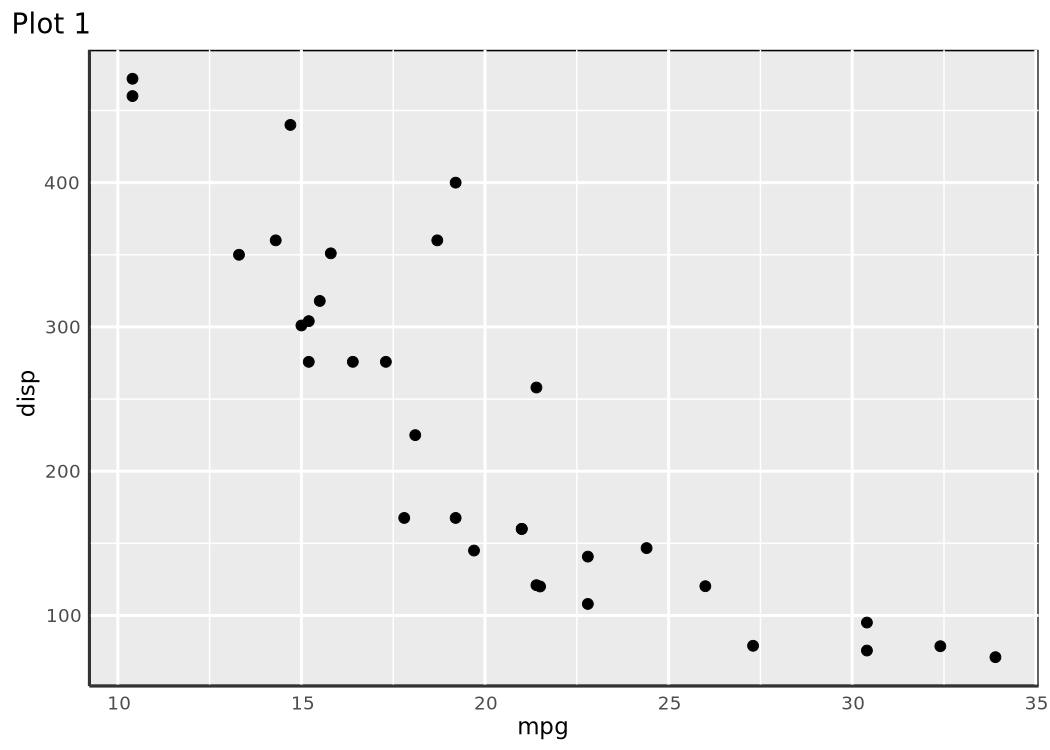

In [2]:
p1

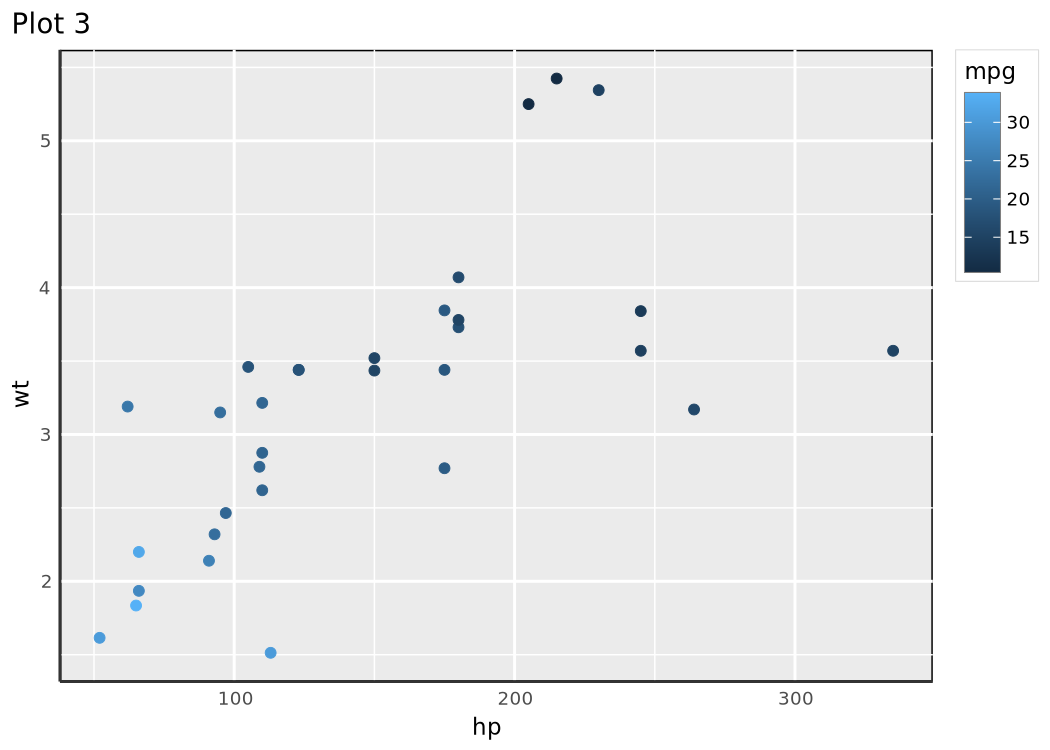

In [3]:
p3

## Aligning to a known target

`get_dim()` extracts the outer-margin dimensions from a plot (widths to the left/right of the panel; heights above/below). `set_dim()` applies a previously-captured dimension object to another plot.

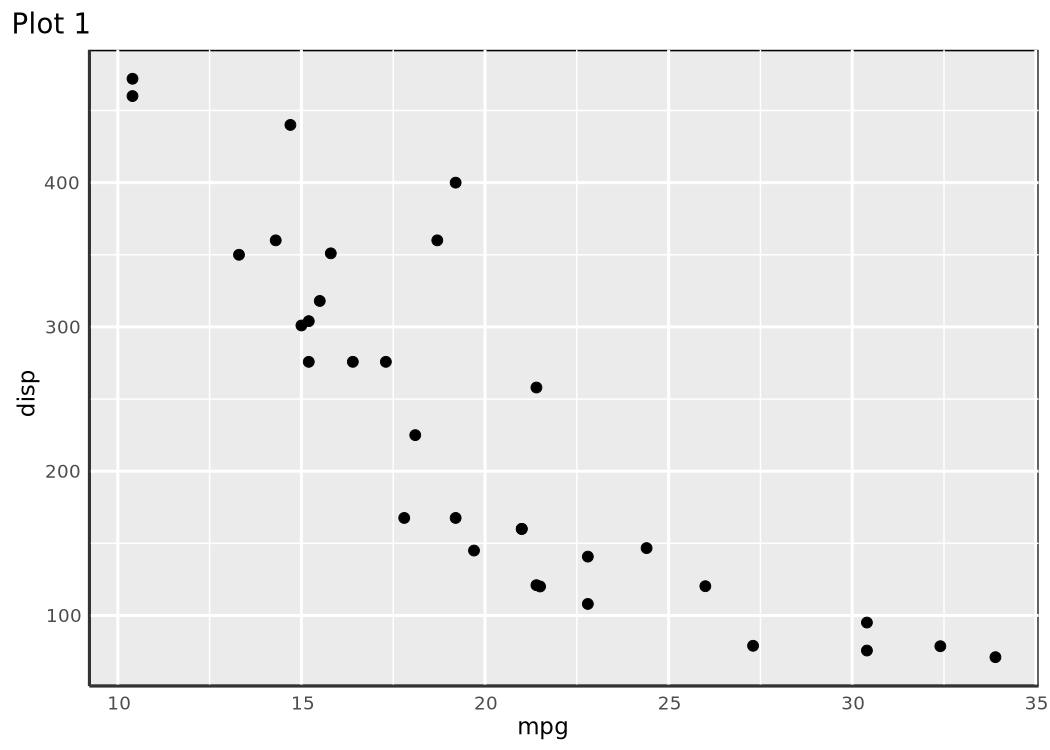

In [4]:
p3_dims = pw.get_dim(p3)
p1_aligned = pw.set_dim(p1, p3_dims)
p1_aligned

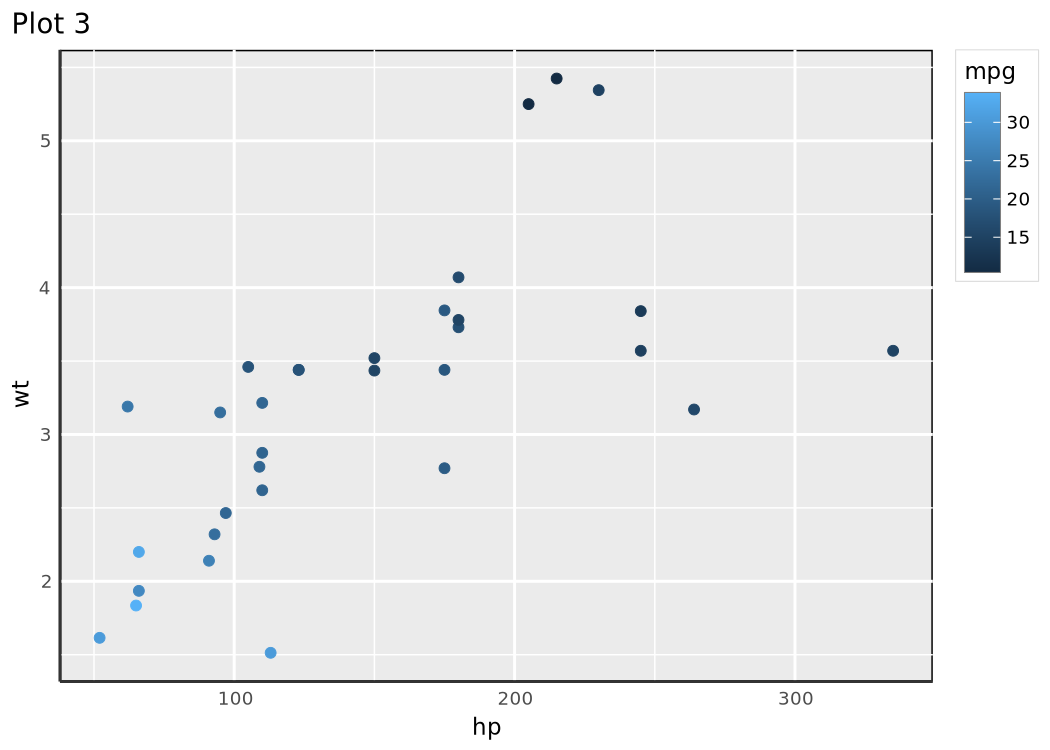

In [5]:
p3

Aligned plots retain their ggplot nature and can continue to be modified:

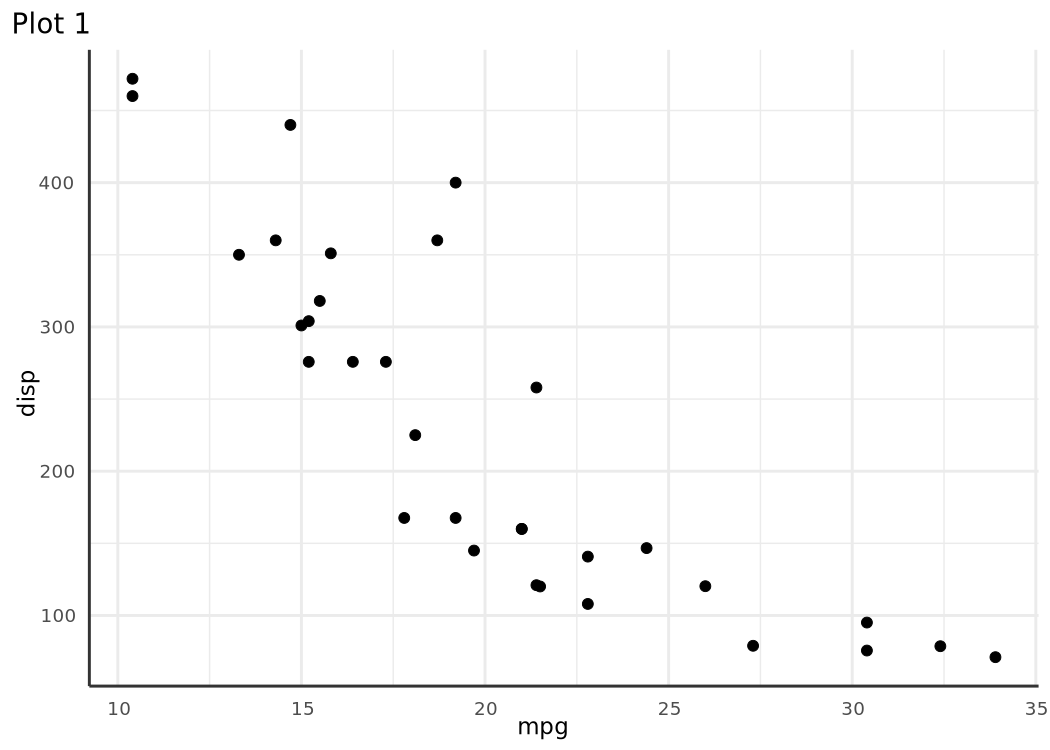

In [6]:
p1_aligned + theme_minimal()

## Aligning to the max dimensions of a set

Often no single plot has the widest margins. `get_max_dim(*plots)` returns the element-wise maximum — safe to align any plot against.

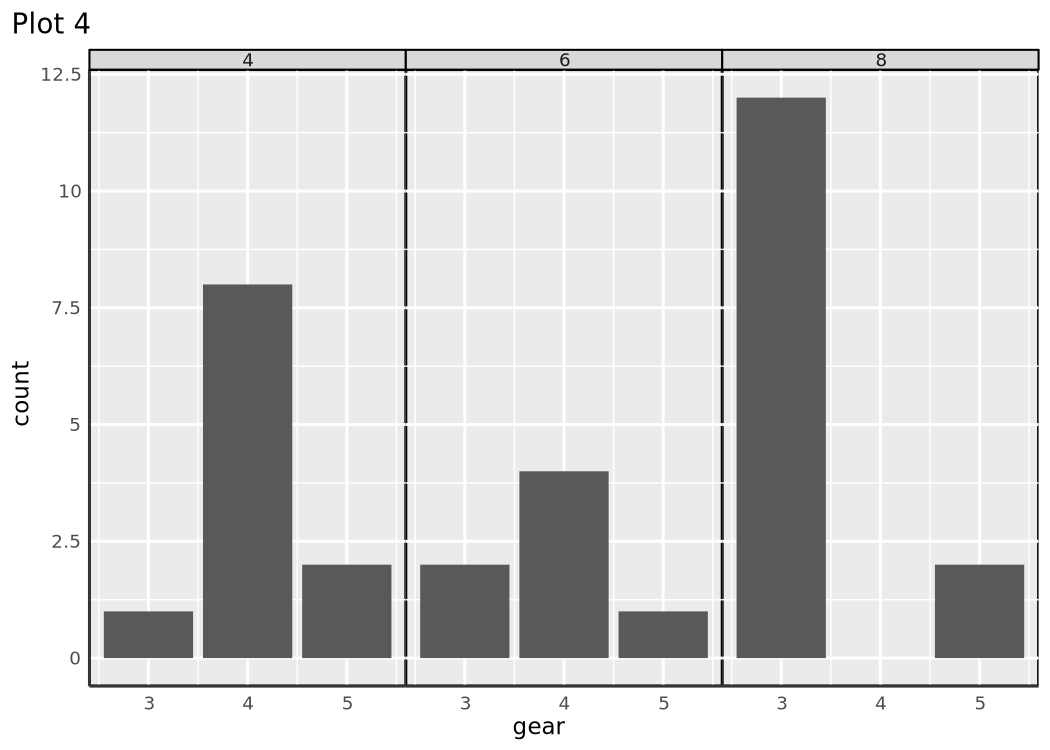

In [7]:
max_dims = pw.get_max_dim(p1, p2, p3, p4)
pw.set_dim(p4, max_dims)

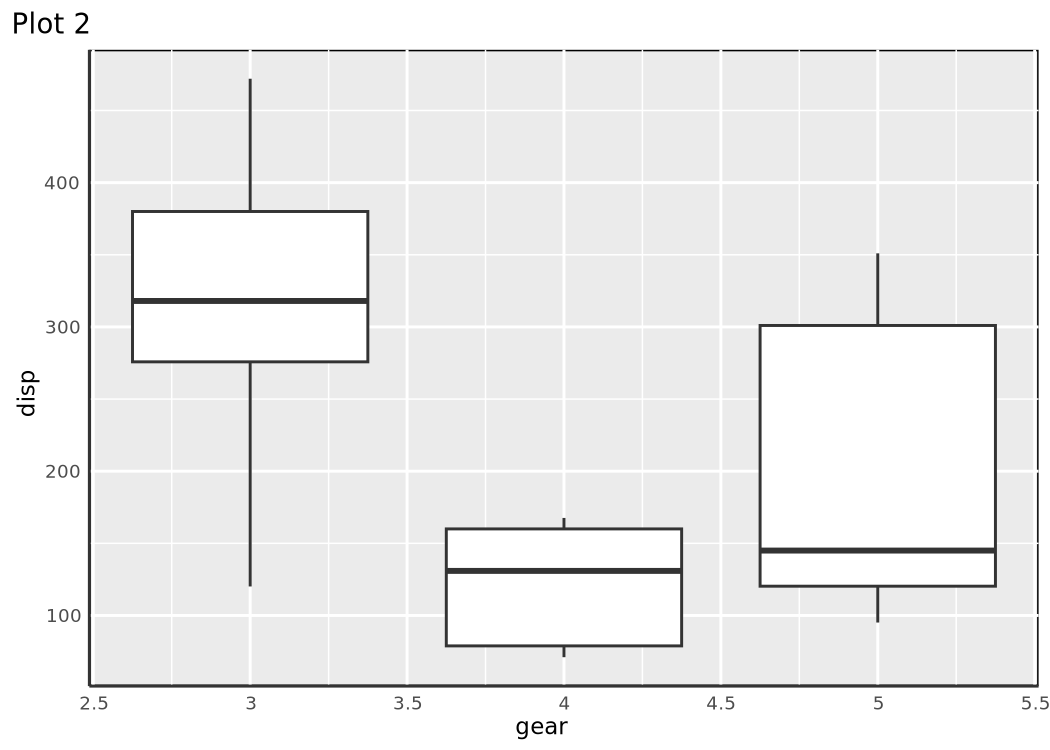

In [8]:
pw.set_dim(p2, max_dims)

## One-shot alignment for a whole set

`align_patches(*plots)` captures `get_max_dim` and applies `set_dim` in a single call, returning a list of aligned plots ready to render one at a time (e.g. into a PDF with multiple pages or into a slideshow).

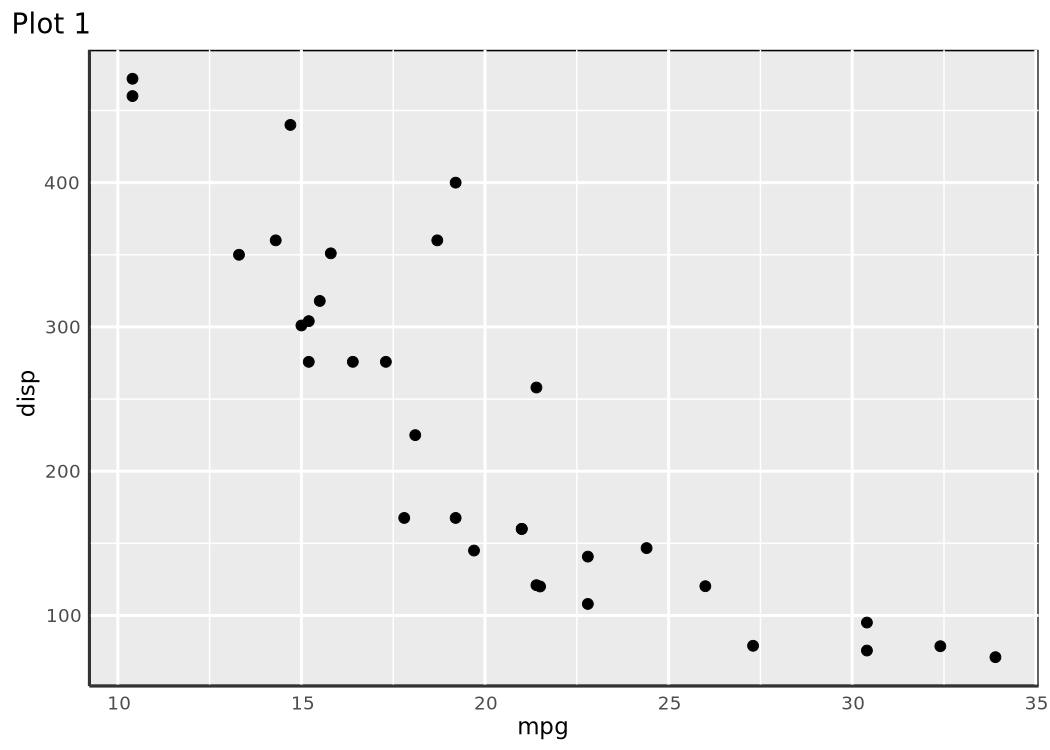

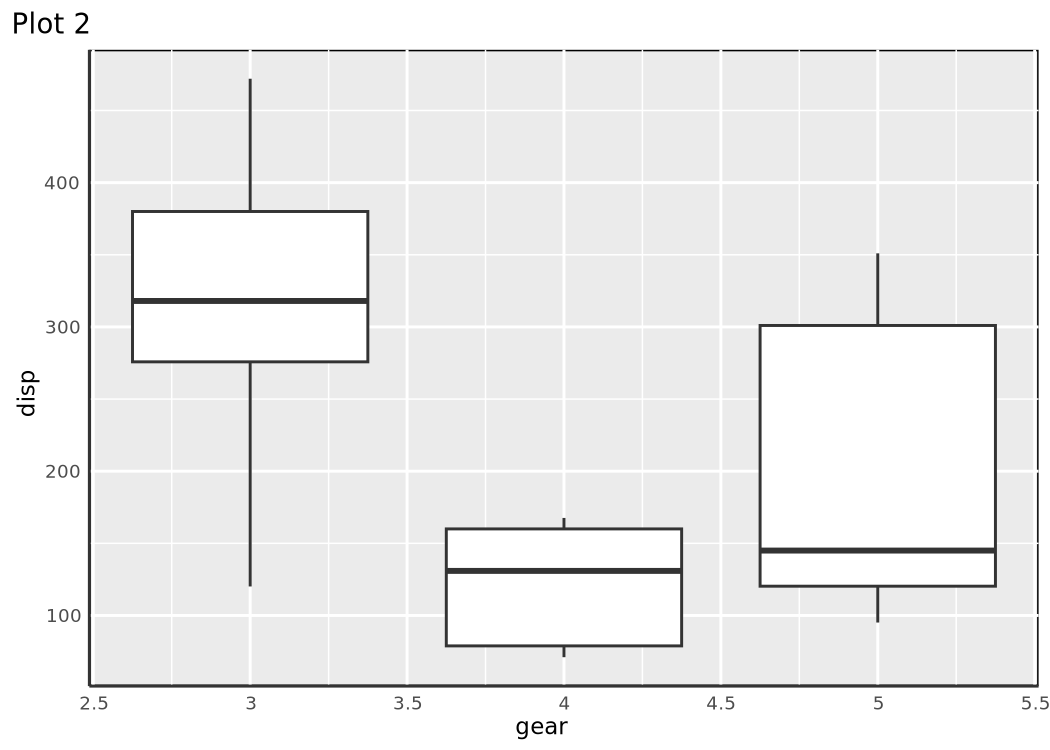

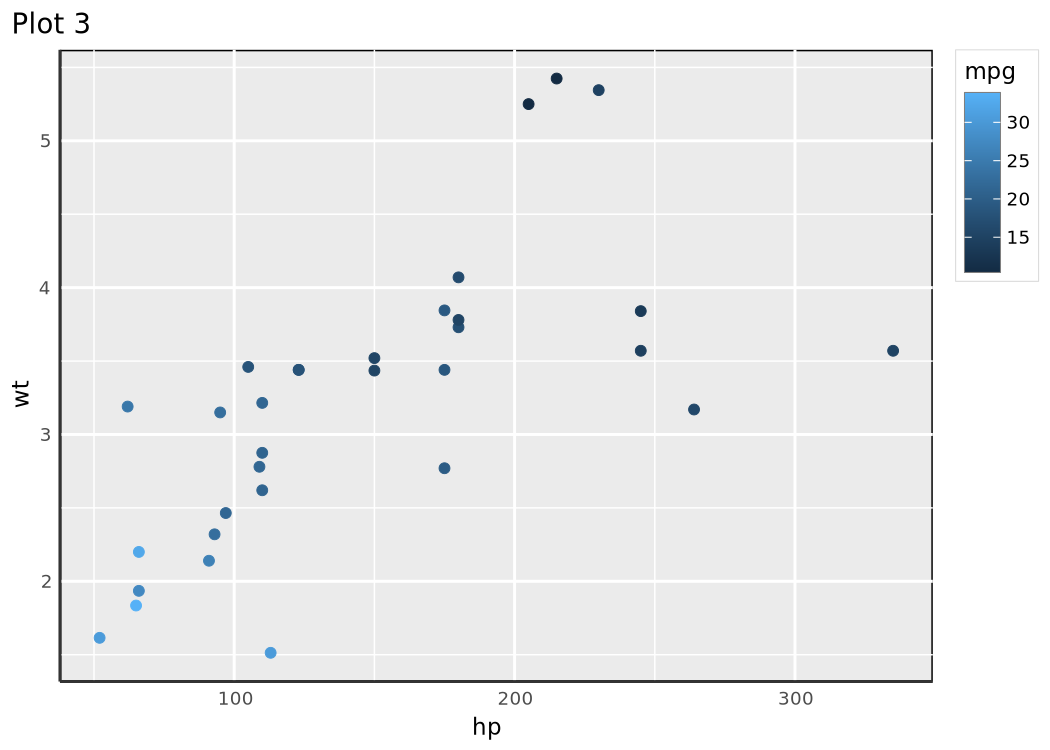

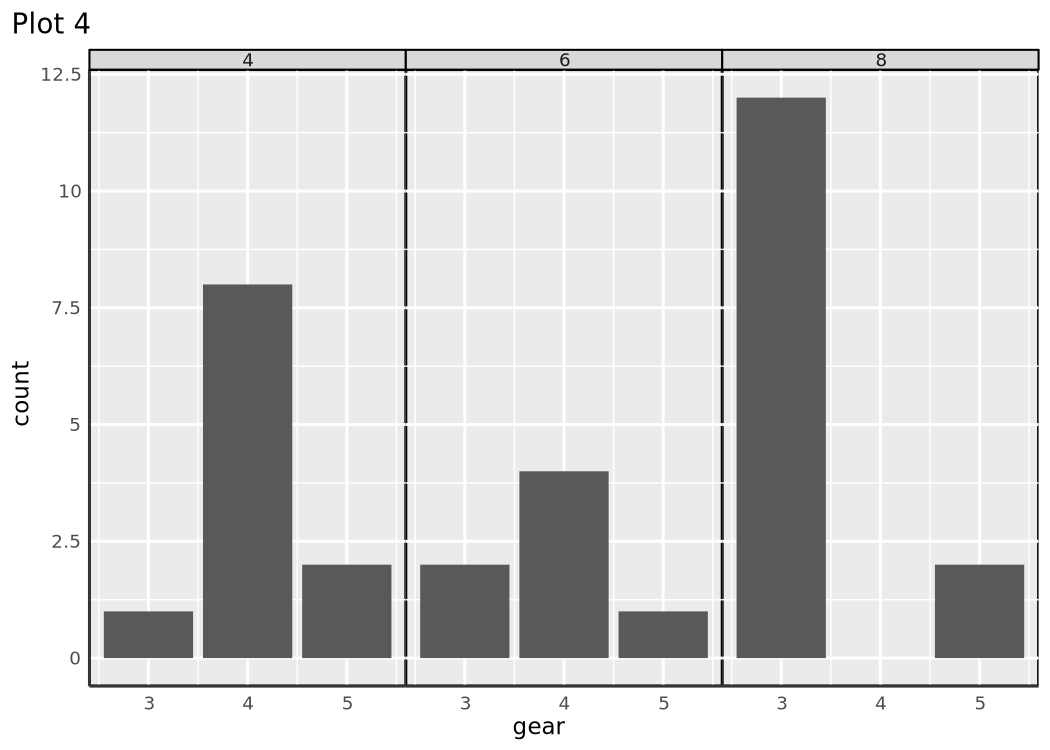

In [9]:
plots_aligned = pw.align_patches(p1, p2, p3, p4)
for p in plots_aligned:
    display(p)

`align_plots` is a deprecated alias for `align_patches` and emits a `DeprecationWarning`.

Aligning patchworks (not bare ggplots) is currently unsupported in both R and this port — calling `get_dim(patchwork)` raises a clear error.